In [5]:
import os
import copy
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split
from tqdm import tqdm

train_dir = "/home/sanjita/ISU_work/assignment/dataTaskA/archive/seg_train/seg_train"
test_dir  = "/home/sanjita/ISU_work/assignment/dataTaskA/archive/seg_test/seg_test"
pred_dir  = "/home/sanjita/ISU_work/assignment/dataTaskA/archive/seg_pred/seg_pred"

output_dir = "/home/sanjita/ISU_work/assignment/result/taskA/light_cnn"
os.makedirs(output_dir, exist_ok=True)

## 1. Lightweight CNN

In [6]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

train_tfms = transforms.Compose([
    transforms.Resize((150, 150)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

test_tfms = transforms.Compose([
    transforms.Resize((150, 150)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

full_train_dataset = datasets.ImageFolder(train_dir, transform=train_tfms)
test_dataset = datasets.ImageFolder(test_dir, transform=test_tfms)

print(full_train_dataset.class_to_idx)

Using device: cuda
GPU: NVIDIA GeForce RTX 4090
{'buildings': 0, 'forest': 1, 'glacier': 2, 'mountain': 3, 'sea': 4, 'street': 5}


In [8]:
val_size = int(0.2 * len(full_train_dataset))
train_size = len(full_train_dataset) - val_size

generator = torch.Generator().manual_seed(42)

train_dataset, val_dataset = random_split(
    full_train_dataset,
    [train_size, val_size],
    generator=generator
)

batch_size = 64

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=4,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=4,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=4,
    pin_memory=True
)

print("Train split:", len(train_dataset))
print("Validation split:", len(val_dataset))
print("Test set:", len(test_dataset))

Train split: 11228
Validation split: 2806
Test set: 3000


In [12]:
import torch.nn as nn

class LightCNN(nn.Module):
    def __init__(self, num_classes=6, dropout=0.2):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            
            nn.Conv2d(256, 512, kernel_size=3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),

            nn.AdaptiveAvgPool2d((1, 1))
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(dropout),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x


def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


model = LightCNN(num_classes=6, dropout=0.2).to(device)

print(model)
print("Trainable parameters:", count_parameters(model))

LightCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU(inplace=True)
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU(inplace=True)
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (12): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): BatchNorm2d(256, eps=1e-05, momentum=0.1, aff

In [13]:
import torch.optim as optim
from tqdm import tqdm

criterion = nn.CrossEntropyLoss()


def train_one_epoch(model, train_loader, criterion, optimizer, device):
    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in tqdm(train_loader, desc="Training", leave=False):
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

        _, preds = torch.max(outputs, dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_acc = correct / total

    return epoch_loss, epoch_acc


def evaluate(model, data_loader, criterion, device):
    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in tqdm(data_loader, desc="Evaluating", leave=False):
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)

            _, preds = torch.max(outputs, dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_acc = correct / total

    return epoch_loss, epoch_acc

In [11]:
# model = LightCNN(num_classes=6, dropout=0.2).to(device)

# optimizer = optim.Adam(model.parameters(), lr=1e-3)

# train_loss, train_acc = train_one_epoch(
#     model, train_loader, criterion, optimizer, device
# )

# val_loss, val_acc = evaluate(
#     model, val_loader, criterion, device
# )

# print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
# print(f"Val Loss:   {val_loss:.4f} | Val Acc:   {val_acc:.4f}")

Train Loss: 0.8790 | Train Acc: 0.6660
Val Loss:   1.0696 | Val Acc:   0.6080


In [15]:
import os
import copy
import matplotlib.pyplot as plt
import torch.optim as optim

output_dir = "/home/sanjita/ISU_work/assignment/result/taskA/light_cnn"
os.makedirs(output_dir, exist_ok=True)


def run_lightcnn_experiment(exp_name, dropout, optimizer_name, lr, epochs=15):
    print("\n" + "=" * 70)
    print(f"Experiment: {exp_name}")
    print("=" * 70)

    model = LightCNN(num_classes=6, dropout=dropout).to(device)
    print("Trainable parameters:", count_parameters(model))

    criterion = nn.CrossEntropyLoss()

    if optimizer_name.lower() == "adam":
        optimizer = optim.Adam(model.parameters(), lr=lr)

    elif optimizer_name.lower() == "sgd":
        optimizer = optim.SGD(model.parameters(), lr=lr, momentum=0.9)

    else:
        raise ValueError("optimizer_name must be either 'adam' or 'sgd'")

    history = {
        "train_loss": [],
        "val_loss": [],
        "train_acc": [],
        "val_acc": []
    }

    best_val_acc = 0.0
    best_model_wts = copy.deepcopy(model.state_dict())

    for epoch in range(epochs):
        print(f"\nEpoch {epoch + 1}/{epochs}")

        train_loss, train_acc = train_one_epoch(
            model, train_loader, criterion, optimizer, device
        )

        val_loss, val_acc = evaluate(
            model, val_loader, criterion, device
        )

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)

        print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
        print(f"Val Loss:   {val_loss:.4f} | Val Acc:   {val_acc:.4f}")

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_model_wts = copy.deepcopy(model.state_dict())

    model.load_state_dict(best_model_wts)

    model_path = os.path.join(output_dir, f"{exp_name}_best_model.pt")
    torch.save(model.state_dict(), model_path)

    print(f"\nBest validation accuracy: {best_val_acc:.4f}")
    print("Saved best model to:", model_path)

    return model, history, best_val_acc


def plot_history(history, exp_name, output_dir):
    epochs = range(1, len(history["train_loss"]) + 1)

    plt.figure(figsize=(7, 5))
    plt.plot(epochs, history["train_loss"], label="Train Loss")
    plt.plot(epochs, history["val_loss"], label="Validation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"{exp_name} - Loss")
    plt.legend()
    plt.grid(True)

    loss_path = os.path.join(output_dir, f"{exp_name}_loss.png")
    plt.savefig(loss_path, dpi=300, bbox_inches="tight")
    plt.show()

    plt.figure(figsize=(7, 5))
    plt.plot(epochs, history["train_acc"], label="Train Accuracy")
    plt.plot(epochs, history["val_acc"], label="Validation Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title(f"{exp_name} - Accuracy")
    plt.legend()
    plt.grid(True)

    acc_path = os.path.join(output_dir, f"{exp_name}_accuracy.png")
    plt.savefig(acc_path, dpi=300, bbox_inches="tight")
    plt.show()

    print("Saved loss plot to:", loss_path)
    print("Saved accuracy plot to:", acc_path)


Experiment: LightCNN_A_adam_lr1e3_dropout02
Trainable parameters: 1573638

Epoch 1/50


Train Loss: 0.8286 | Train Acc: 0.6860
Val Loss:   0.6865 | Val Acc:   0.7195

Epoch 2/50


Train Loss: 0.6144 | Train Acc: 0.7733
Val Loss:   0.5504 | Val Acc:   0.7986

Epoch 3/50


Train Loss: 0.5365 | Train Acc: 0.8077
Val Loss:   0.8268 | Val Acc:   0.6996

Epoch 4/50


Train Loss: 0.4967 | Train Acc: 0.8188
Val Loss:   0.5524 | Val Acc:   0.8022

Epoch 5/50


...

Train Loss: 0.1651 | Train Acc: 0.9375
Val Loss:   0.3665 | Val Acc:   0.8881

Epoch 47/50


Train Loss: 0.1627 | Train Acc: 0.9390
Val Loss:   0.3624 | Val Acc:   0.8813

Epoch 48/50


Train Loss: 0.1653 | Train Acc: 0.9401
Val Loss:   0.3368 | Val Acc:   0.8924

Epoch 49/50


Train Loss: 0.1571 | Train Acc: 0.9426
Val Loss:   0.3850 | Val Acc:   0.8803

Epoch 50/50


Train Loss: 0.1615 | Train Acc: 0.9410
Val Loss:   0.3956 | Val Acc:   0.8781

Best validation accuracy: 0.9016
Saved best model to: /home/sanjita/ISU_work/assignment/result/taskA/light_cnn/LightCNN_A_adam_lr1e3_dropout02_best_model.pt


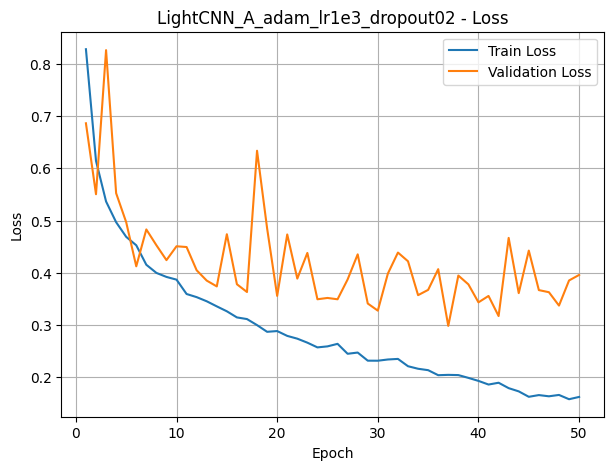

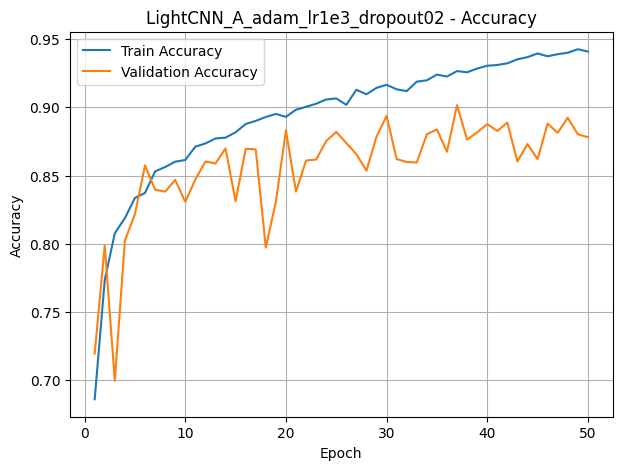

Saved loss plot to: /home/sanjita/ISU_work/assignment/result/taskA/light_cnn/LightCNN_A_adam_lr1e3_dropout02_loss.png
Saved accuracy plot to: /home/sanjita/ISU_work/assignment/result/taskA/light_cnn/LightCNN_A_adam_lr1e3_dropout02_accuracy.png

Experiment: LightCNN_B_sgd_lr3e4_dropout05
Trainable parameters: 1573638

Epoch 1/50


Train Loss: 1.3610 | Train Acc: 0.4631
Val Loss:   1.1246 | Val Acc:   0.5802

Epoch 2/50


Train Loss: 1.0787 | Train Acc: 0.5901
Val Loss:   0.9551 | Val Acc:   0.6507

Epoch 3/50


Train Loss: 0.9434 | Train Acc: 0.6498
Val Loss:   0.8484 | Val Acc:   0.6978

Epoch 4/50


Train Loss: 0.8442 | Train Acc: 0.6898
Val Loss:   0.8060 | Val Acc:   0.7063

Epoch 5/50


...

Train Loss: 0.3942 | Train Acc: 0.8566
Val Loss:   0.5589 | Val Acc:   0.7915

Epoch 47/50


Train Loss: 0.3894 | Train Acc: 0.8615
Val Loss:   0.4354 | Val Acc:   0.8553

Epoch 48/50


Train Loss: 0.3816 | Train Acc: 0.8615
Val Loss:   0.4416 | Val Acc:   0.8378

Epoch 49/50


Train Loss: 0.3902 | Train Acc: 0.8586
Val Loss:   0.4505 | Val Acc:   0.8411

Epoch 50/50


Train Loss: 0.3747 | Train Acc: 0.8671
Val Loss:   0.4042 | Val Acc:   0.8510

Best validation accuracy: 0.8553
Saved best model to: /home/sanjita/ISU_work/assignment/result/taskA/light_cnn/LightCNN_B_sgd_lr3e4_dropout05_best_model.pt


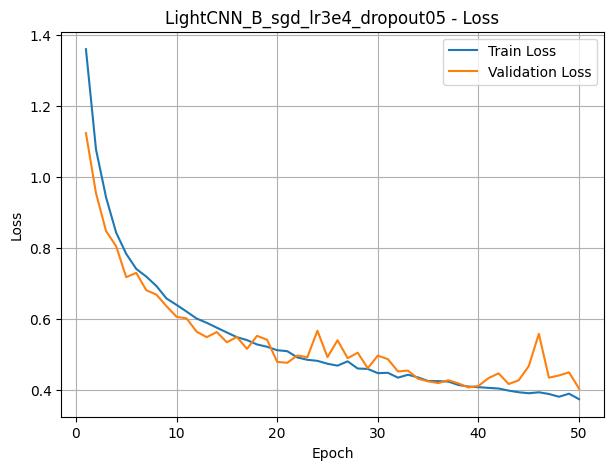

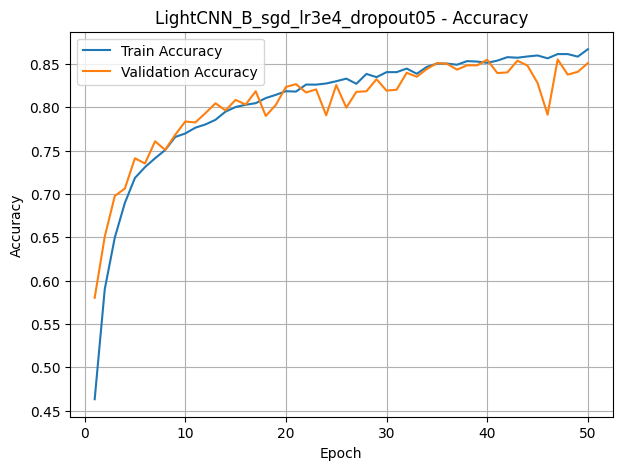

Saved loss plot to: /home/sanjita/ISU_work/assignment/result/taskA/light_cnn/LightCNN_B_sgd_lr3e4_dropout05_loss.png
Saved accuracy plot to: /home/sanjita/ISU_work/assignment/result/taskA/light_cnn/LightCNN_B_sgd_lr3e4_dropout05_accuracy.png

Lightweight CNN Experiment Summary
------------------------------------------------------------
LightCNN A | Adam | lr=1e-3 | dropout=0.2 | Best Val Acc: 0.9016
LightCNN B | SGD  | lr=3e-4 | dropout=0.5 | Best Val Acc: 0.8553


In [22]:
model_a, history_a, best_acc_a = run_lightcnn_experiment(
    exp_name="LightCNN_A_adam_lr1e3_dropout02",
    dropout=0.2,
    optimizer_name="adam",
    lr=1e-3,
    epochs=50
)

plot_history(history_a, "LightCNN_A_adam_lr1e3_dropout02", output_dir)


model_b, history_b, best_acc_b = run_lightcnn_experiment(
    exp_name="LightCNN_B_sgd_lr3e4_dropout05",
    dropout=0.5,
    optimizer_name="sgd",
    lr=3e-4,
    epochs=50
)

plot_history(history_b, "LightCNN_B_sgd_lr3e4_dropout05", output_dir)


print("\nLightweight CNN Experiment Summary")
print("-" * 60)
print(f"LightCNN A | Adam | lr=1e-3 | dropout=0.2 | Best Val Acc: {best_acc_a:.4f}")
print(f"LightCNN B | SGD  | lr=3e-4 | dropout=0.5 | Best Val Acc: {best_acc_b:.4f}")

## 2. Deeper CNN

In [17]:
from torchvision import models
import torch.nn as nn

class DeepCNN_ResNet18(nn.Module):
    def __init__(self, num_classes=6, dropout=0.2):
        super().__init__()

        self.model = models.resnet18(weights=None)

        in_features = self.model.fc.in_features

        self.model.fc = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(in_features, num_classes)
        )

    def forward(self, x):
        return self.model(x)
    
deep_model = DeepCNN_ResNet18(num_classes=6, dropout=0.2).to(device)

print(deep_model)
print("Trainable parameters:", count_parameters(deep_model))

DeepCNN_ResNet18(
  (model): ResNet(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, tr

In [19]:
deep_output_dir = "/home/sanjita/ISU_work/assignment/result/taskA/deep_cnn"
os.makedirs(deep_output_dir, exist_ok=True)


def run_deepcnn_experiment(exp_name, dropout, optimizer_name, lr, epochs=15):
    print("\n" + "=" * 70)
    print(f"Experiment: {exp_name}")
    print("=" * 70)

    model = DeepCNN_ResNet18(num_classes=6, dropout=dropout).to(device)
    print("Trainable parameters:", count_parameters(model))

    criterion = nn.CrossEntropyLoss()

    if optimizer_name.lower() == "adam":
        optimizer = optim.Adam(model.parameters(), lr=lr)

    elif optimizer_name.lower() == "sgd":
        optimizer = optim.SGD(model.parameters(), lr=lr, momentum=0.9)

    else:
        raise ValueError("optimizer_name must be either 'adam' or 'sgd'")

    history = {
        "train_loss": [],
        "val_loss": [],
        "train_acc": [],
        "val_acc": []
    }

    best_val_acc = 0.0
    best_model_wts = copy.deepcopy(model.state_dict())

    for epoch in range(epochs):
        print(f"\nEpoch {epoch + 1}/{epochs}")

        train_loss, train_acc = train_one_epoch(
            model, train_loader, criterion, optimizer, device
        )

        val_loss, val_acc = evaluate(
            model, val_loader, criterion, device
        )

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)

        print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
        print(f"Val Loss:   {val_loss:.4f} | Val Acc:   {val_acc:.4f}")

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_model_wts = copy.deepcopy(model.state_dict())

    model.load_state_dict(best_model_wts)

    model_path = os.path.join(deep_output_dir, f"{exp_name}_best_model.pt")
    torch.save(model.state_dict(), model_path)

    print(f"\nBest validation accuracy: {best_val_acc:.4f}")
    print("Saved best model to:", model_path)

    return model, history, best_val_acc


Experiment: DeepCNN_A_resnet18_adam_lr1e3_dropout02
Trainable parameters: 11179590

Epoch 1/50


Train Loss: 0.9122 | Train Acc: 0.6536
Val Loss:   0.7917 | Val Acc:   0.7120

Epoch 2/50


Train Loss: 0.6535 | Train Acc: 0.7614
Val Loss:   0.9285 | Val Acc:   0.6892

Epoch 3/50


Train Loss: 0.5780 | Train Acc: 0.7925
Val Loss:   0.6920 | Val Acc:   0.7341

Epoch 4/50


Train Loss: 0.5275 | Train Acc: 0.8121
Val Loss:   0.4933 | Val Acc:   0.8239

Epoch 5/50


...

Train Loss: 0.0670 | Train Acc: 0.9756
Val Loss:   0.6409 | Val Acc:   0.8482

Epoch 47/50


Train Loss: 0.0623 | Train Acc: 0.9787
Val Loss:   0.4776 | Val Acc:   0.8852

Epoch 48/50


Train Loss: 0.0583 | Train Acc: 0.9787
Val Loss:   0.5000 | Val Acc:   0.8831

Epoch 49/50


Train Loss: 0.0685 | Train Acc: 0.9759
Val Loss:   0.4920 | Val Acc:   0.8842

Epoch 50/50


Train Loss: 0.0497 | Train Acc: 0.9823
Val Loss:   0.5769 | Val Acc:   0.8703

Best validation accuracy: 0.8863
Saved best model to: /home/sanjita/ISU_work/assignment/result/taskA/deep_cnn/DeepCNN_A_resnet18_adam_lr1e3_dropout02_best_model.pt


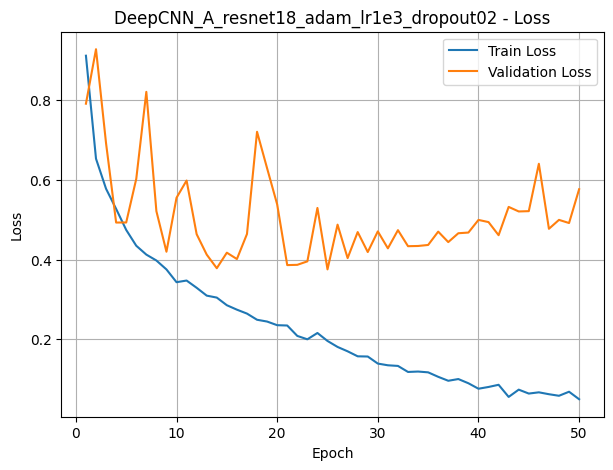

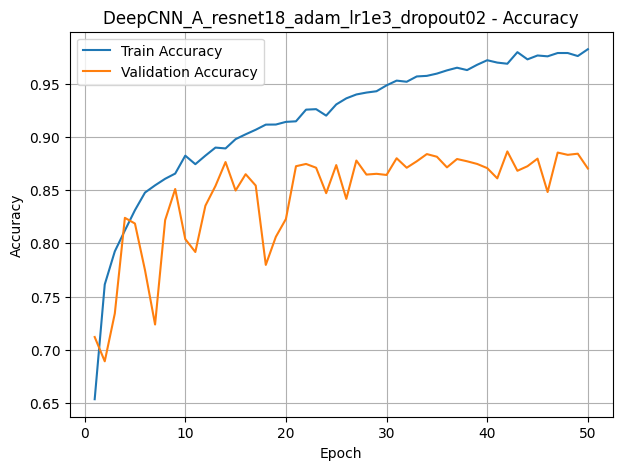

Saved loss plot to: /home/sanjita/ISU_work/assignment/result/taskA/deep_cnn/DeepCNN_A_resnet18_adam_lr1e3_dropout02_loss.png
Saved accuracy plot to: /home/sanjita/ISU_work/assignment/result/taskA/deep_cnn/DeepCNN_A_resnet18_adam_lr1e3_dropout02_accuracy.png

Experiment: DeepCNN_B_resnet18_sgd_lr3e4_dropout05
Trainable parameters: 11179590

Epoch 1/50


Train Loss: 1.5770 | Train Acc: 0.3260
Val Loss:   1.2229 | Val Acc:   0.5342

Epoch 2/50


Train Loss: 1.1999 | Train Acc: 0.4923
Val Loss:   1.0195 | Val Acc:   0.6066

Epoch 3/50


Train Loss: 1.0487 | Train Acc: 0.5653
Val Loss:   0.9376 | Val Acc:   0.6301

Epoch 4/50


Train Loss: 0.9469 | Train Acc: 0.6150
Val Loss:   0.8729 | Val Acc:   0.6675

Epoch 5/50


...

Train Loss: 0.3303 | Train Acc: 0.8823
Val Loss:   0.3980 | Val Acc:   0.8585

Epoch 47/50


Train Loss: 0.3259 | Train Acc: 0.8842
Val Loss:   0.3934 | Val Acc:   0.8685

Epoch 48/50


Train Loss: 0.3188 | Train Acc: 0.8860
Val Loss:   0.3922 | Val Acc:   0.8614

Epoch 49/50


Train Loss: 0.3249 | Train Acc: 0.8822
Val Loss:   0.4361 | Val Acc:   0.8471

Epoch 50/50


Train Loss: 0.3221 | Train Acc: 0.8830
Val Loss:   0.4350 | Val Acc:   0.8393

Best validation accuracy: 0.8685
Saved best model to: /home/sanjita/ISU_work/assignment/result/taskA/deep_cnn/DeepCNN_B_resnet18_sgd_lr3e4_dropout05_best_model.pt


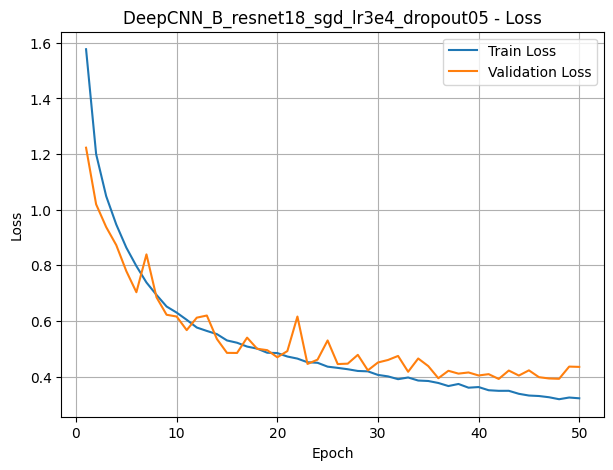

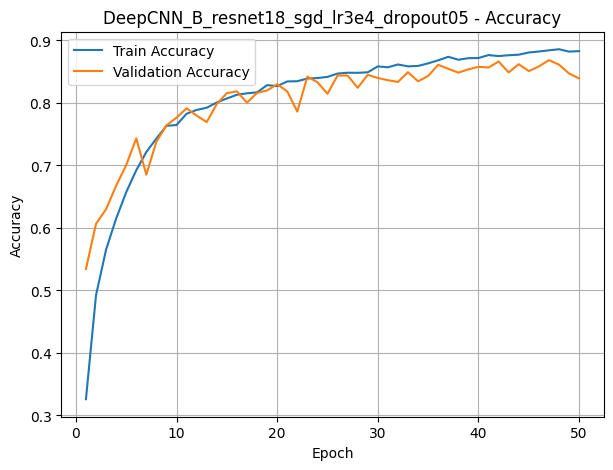

Saved loss plot to: /home/sanjita/ISU_work/assignment/result/taskA/deep_cnn/DeepCNN_B_resnet18_sgd_lr3e4_dropout05_loss.png
Saved accuracy plot to: /home/sanjita/ISU_work/assignment/result/taskA/deep_cnn/DeepCNN_B_resnet18_sgd_lr3e4_dropout05_accuracy.png

Deeper CNN Experiment Summary
------------------------------------------------------------
DeepCNN A | ResNet-18 | Adam | lr=1e-3 | dropout=0.2 | Best Val Acc: 0.8863
DeepCNN B | ResNet-18 | SGD  | lr=3e-4 | dropout=0.5 | Best Val Acc: 0.8685


In [21]:
deep_model_a, deep_history_a, deep_best_acc_a = run_deepcnn_experiment(
    exp_name="DeepCNN_A_resnet18_adam_lr1e3_dropout02",
    dropout=0.2,
    optimizer_name="adam",
    lr=1e-3,
    epochs=50
)

plot_history(
    deep_history_a,
    "DeepCNN_A_resnet18_adam_lr1e3_dropout02",
    deep_output_dir
)


deep_model_b, deep_history_b, deep_best_acc_b = run_deepcnn_experiment(
    exp_name="DeepCNN_B_resnet18_sgd_lr3e4_dropout05",
    dropout=0.5,
    optimizer_name="sgd",
    lr=3e-4,
    epochs=50
)

plot_history(
    deep_history_b,
    "DeepCNN_B_resnet18_sgd_lr3e4_dropout05",
    deep_output_dir
)


print("\nDeeper CNN Experiment Summary")
print("-" * 60)
print(f"DeepCNN A | ResNet-18 | Adam | lr=1e-3 | dropout=0.2 | Best Val Acc: {deep_best_acc_a:.4f}")
print(f"DeepCNN B | ResNet-18 | SGD  | lr=3e-4 | dropout=0.5 | Best Val Acc: {deep_best_acc_b:.4f}")